# Recentered Label Generation

Generates three new 5-class label CSVs with shifted coordinate origins:

| Variant | Shift | Rationale |
|---------|-------|-----------|
| **Naive** | (0.37, -1.36) | Data centroid — average across all devices/orientations |
| **Balanced** | (-0.30, -3.60) | Optimized to minimize 4-class max/min ratio (1.70x) |
| **Aggressive** | (0.66, -5.92) | iPhone portrait screen center — matches deployment target |

Same `label_pog_5` logic as the original EDA. Training pipeline filters out Straight as usual.
Original labels are not modified.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
LABELS_PATH = './gaze_labels.csv'

df = pd.read_csv(LABELS_PATH)
print(f"Loaded {len(df):,} rows")
print(f"\nOriginal 5-class distribution:")
for lbl, ct in sorted(df['label'].value_counts().items()):
    print(f"  {lbl:10s}: {ct:>7,}  ({ct/len(df)*100:.1f}%)")

Loaded 849,131 rows

Original 5-class distribution:
  Down      : 213,320  (25.1%)
  Left      : 188,773  (22.2%)
  Right     : 180,056  (21.2%)
  Straight  : 246,664  (29.0%)
  Up        :  20,318  (2.4%)


In [7]:
def label_pog_5(x, y, threshold=4):
    if abs(x) < threshold and abs(y) < threshold:
        return 'Straight'
    elif abs(x) > abs(y):
        return 'Left' if x < 0 else 'Right'
    else:
        return 'Down' if y < 0 else 'Up'


shifts = {
    'naive':      ( 0.37, -1.36),  # data centroid
    'balanced':   (-0.30, -3.60),  # optimized for 4-class balance (1.70x ratio)
    'aggressive': ( 0.66, -5.92),  # avg iPhone portrait screen center
}

In [8]:
# ============================================================
# Generate labels for all three shifts
# ============================================================

for name, (cx, cy) in shifts.items():
    col = f'label_{name}'
    df[col] = [label_pog_5(x - cx, y - cy) for x, y in zip(df['pog_x'], df['pog_y'])]

    print(f"\n{'='*50}")
    print(f"{name.upper()} — shift ({cx}, {cy})")
    print(f"{'='*50}")
    for lbl in ['Up', 'Down', 'Left', 'Right', 'Straight']:
        ct = (df[col] == lbl).sum()
        print(f"  {lbl:10s}: {ct:>7,}  ({ct/len(df)*100:.1f}%)")


NAIVE — shift (0.37, -1.36)
  Up        :  31,564  (3.7%)
  Down      : 183,016  (21.6%)
  Left      : 208,435  (24.5%)
  Right     : 171,128  (20.2%)
  Straight  : 254,988  (30.0%)

BALANCED — shift (-0.3, -3.6)
  Up        : 111,441  (13.1%)
  Down      : 102,624  (12.1%)
  Left      : 172,884  (20.4%)
  Right     : 174,189  (20.5%)
  Straight  : 287,993  (33.9%)

AGGRESSIVE — shift (0.66, -5.92)
  Up        : 294,748  (34.7%)
  Down      :  39,493  (4.7%)
  Left      : 168,186  (19.8%)
  Right     : 105,004  (12.4%)
  Straight  : 241,700  (28.5%)


In [9]:
# ============================================================
# Side-by-side comparison table
# ============================================================

print(f"{'5-class':12s} {'Original':>10s} {'Naive':>10s} {'Balanced':>10s} {'Aggressive':>12s}")
print("-" * 58)
for lbl in ['Up', 'Down', 'Left', 'Right', 'Straight']:
    ct_o = (df['label'] == lbl).sum()
    ct_n = (df['label_naive'] == lbl).sum()
    ct_b = (df['label_balanced'] == lbl).sum()
    ct_a = (df['label_aggressive'] == lbl).sum()
    print(f"  {lbl:10s} {ct_o:>8,}   {ct_n:>8,}   {ct_b:>8,}   {ct_a:>10,}")

# 4-class view (what the model actually trains on)
print(f"\n{'4-class':12s} {'Original':>10s} {'Naive':>10s} {'Balanced':>10s} {'Aggressive':>12s}")
print("-" * 58)
for lbl in ['Up', 'Down', 'Left', 'Right']:
    vals = []
    for col in ['label', 'label_naive', 'label_balanced', 'label_aggressive']:
        non_straight = df[df[col] != 'Straight']
        ct = (non_straight[col] == lbl).sum()
        vals.append(ct)
    print(f"  {lbl:10s} {vals[0]:>8,}   {vals[1]:>8,}   {vals[2]:>8,}   {vals[3]:>10,}")

# Max/min ratios
print(f"\n  4-class max/min ratio:")
for name, col in [('Original','label'), ('Naive','label_naive'),
                   ('Balanced','label_balanced'), ('Aggressive','label_aggressive')]:
    non_straight = df[df[col] != 'Straight']
    cts = [((non_straight[col] == l).sum()) for l in ['Up','Down','Left','Right']]
    ratio = max(cts) / max(min(cts), 1)
    print(f"    {name:12s}: {ratio:.2f}x")

5-class        Original      Naive   Balanced   Aggressive
----------------------------------------------------------
  Up           20,318     31,564    111,441      294,748
  Down        213,320    183,016    102,624       39,493
  Left        188,773    208,435    172,884      168,186
  Right       180,056    171,128    174,189      105,004
  Straight    246,664    254,988    287,993      241,700

4-class        Original      Naive   Balanced   Aggressive
----------------------------------------------------------
  Up           20,318     31,564    111,441      294,748
  Down        213,320    183,016    102,624       39,493
  Left        188,773    208,435    172,884      168,186
  Right       180,056    171,128    174,189      105,004

  4-class max/min ratio:
    Original    : 10.50x
    Naive       : 6.60x
    Balanced    : 1.70x
    Aggressive  : 7.46x


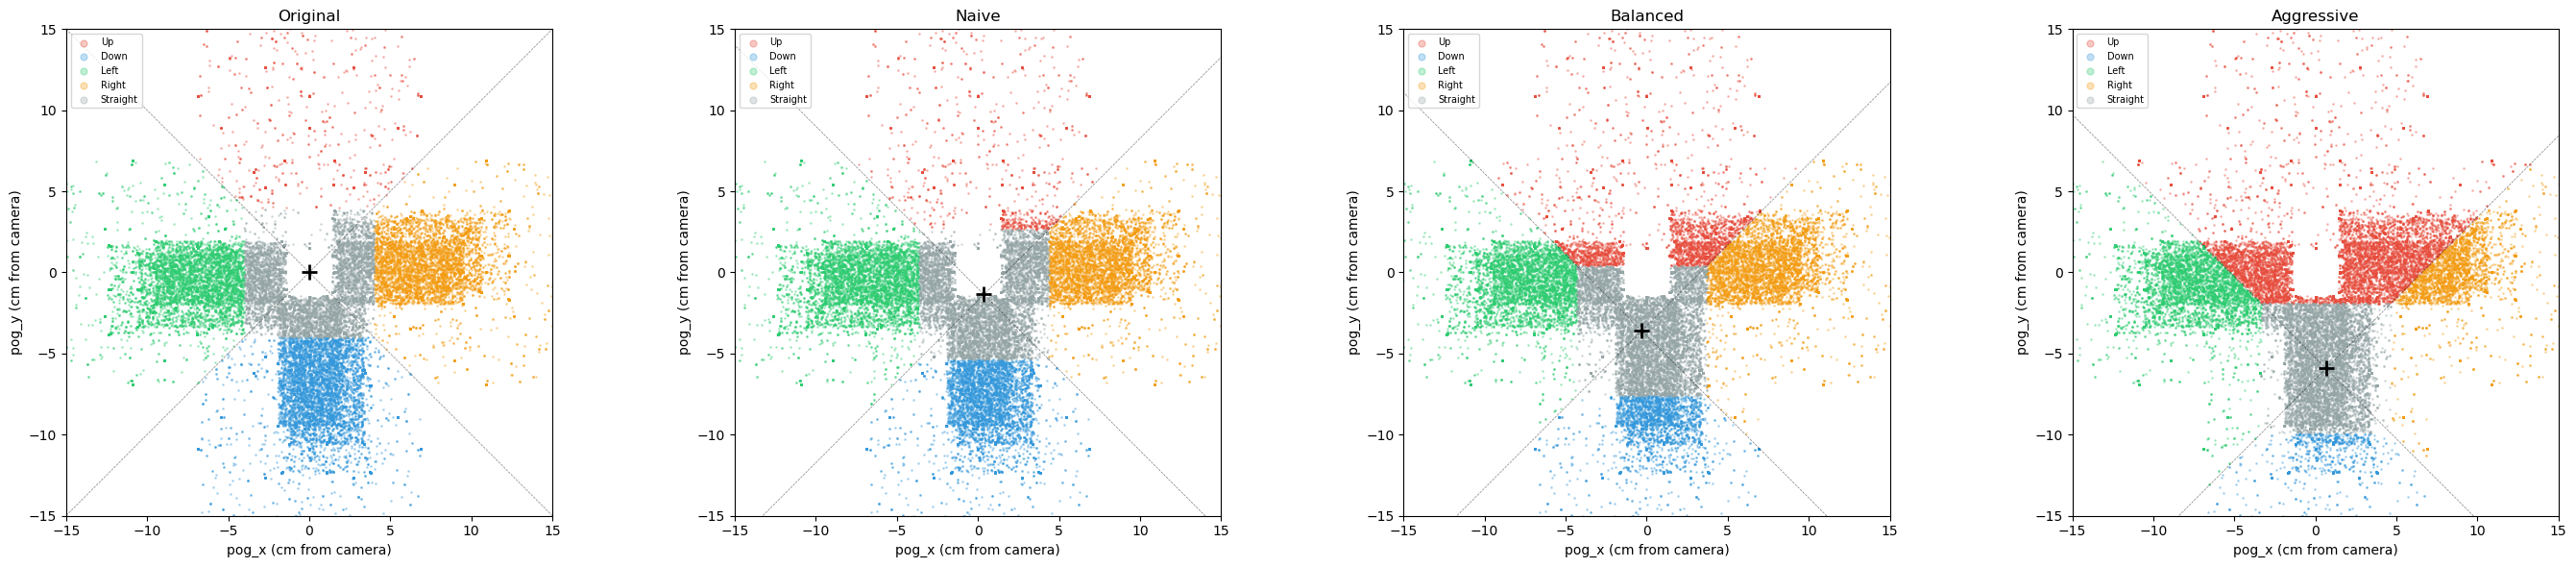

In [10]:
# ============================================================
# Visual comparison — 4 panels
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(28, 6))

sample = df.sample(n=min(50_000, len(df)), random_state=42)
colors = {'Up': '#e74c3c', 'Down': '#3498db', 'Left': '#2ecc71',
          'Right': '#f39c12', 'Straight': '#95a5a6'}

configs = [
    ('label',            0,     0,     'Original'),
    ('label_naive',      0.37, -1.36,  'Naive'),
    ('label_balanced',  -0.30, -3.60,  'Balanced'),
    ('label_aggressive', 0.66, -5.92,  'Aggressive'),
]

for ax, (lbl_col, cx, cy, title) in zip(axes, configs):
    for label, color in colors.items():
        mask = sample[lbl_col] == label
        if mask.sum() > 0:
            ax.scatter(sample.loc[mask, 'pog_x'], sample.loc[mask, 'pog_y'],
                       c=color, s=1, alpha=0.3, label=label)

    lim = 20
    ax.plot([cx-lim, cx+lim], [cy-lim, cy+lim], 'k--', linewidth=0.5, alpha=0.5)
    ax.plot([cx-lim, cx+lim], [cy+lim, cy-lim], 'k--', linewidth=0.5, alpha=0.5)
    ax.plot(cx, cy, 'k+', markersize=12, markeredgewidth=2)

    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)
    ax.set_aspect('equal')
    ax.set_xlabel('pog_x (cm from camera)')
    ax.set_ylabel('pog_y (cm from camera)')
    ax.set_title(title)
    ax.legend(markerscale=5, loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Save — same format as original gaze_labels.csv
# !!! UPDATE OUTPUT DIR
# ============================================================

OUTPUT_DIR = '.'

for name in ['naive', 'balanced', 'aggressive']:
    out = df[['subject_id', 'frame_idx', 'pog_x', 'pog_y']].copy()
    out['label'] = df[f'label_{name}']

    fname = f'{OUTPUT_DIR}/gaze_labels_{name}.csv'
    out.to_csv(fname, index=False)
    print(f"Saved {fname} ({len(out):,} rows)")

print("\nOriginal gaze_labels.csv is unchanged.")

Saved ./gaze_labels_naive.csv (849,131 rows)
Saved ./gaze_labels_balanced.csv (849,131 rows)
Saved ./gaze_labels_aggressive.csv (849,131 rows)

Original gaze_labels.csv is unchanged.
